<h1 align="center">Backpropagation Code </h1>

## Customer Churn Prediction - Binary Classification

In [10]:
# importing Libraries 

import pandas as pd
import numpy as np 

In [11]:
df = pd.read_csv("/Users/piyush/Repositories/Deep-Learning/Datasets/Churn_Modelling.csv")

In [12]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
# Finding the Basic Information 

# Null Values 

df.info() # no null values , and the dtypes are quite upto for prediction 


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [14]:
# another thing to look up on is if the rows are duplicated
df.duplicated().sum() # total numbers of rows which are duplicated , which are none 

np.int64(0)

In [15]:
# checking how many customers have left the bank and how many still are there 
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [16]:
# checking how many customers have left the bank and how many still are there 
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [17]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [18]:
# removing first three columns -> no need

df.drop(columns=['RowNumber','CustomerId','Surname'] , inplace=True)

In [19]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [20]:
# now our first task is to make categorical data into one hot encoding 

df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first= True)

In [21]:
# scaling the values for faster converging of neural network 

# importing sklearn 

X = df.drop(columns=['Exited']) # droping exited col to get all the features 
y = df['Exited'] # exited as our actual output 

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y , test_size=0.2 , random_state=1)

In [22]:
# checking the shapes 
X_train.shape , y_train.shape , X_test.shape , y_test.shape

((8000, 11), (8000,), (2000, 11), (2000,))

In [23]:
# now we will scale the output 

from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 

X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)


In [24]:
# checking the values 
X_train_scale , X_test_scale

(array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
         -0.57273139,  0.91509065],
        [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
         -0.57273139, -1.09278791],
        [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
         -0.57273139, -1.09278791],
        ...,
        [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
         -0.57273139, -1.09278791],
        [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
         -0.57273139, -1.09278791],
        [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
         -0.57273139,  0.91509065]], shape=(8000, 11)),
 array([[-1.03768121,  0.77498705, -1.0482813 , ..., -0.58312392,
         -0.57273139,  0.91509065],
        [ 0.30708683, -0.46686456, -0.70174202, ..., -0.58312392,
         -0.57273139,  0.91509065],
        [-1.23422423,  0.29735181, -1.0482813 , ..., -0.58312392,
         -0.57273139, -1.09278791],
        ...,
        [-0.86182692, -0.46686456,  

In [25]:
# importing the libraries for building the model 

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

In [26]:
# initializing the layers 

model = Sequential() 

# hidden layer 

model.add(Dense(3,activation='sigmoid',input_dim = 11 ))

# output layer 

model.add(Dense(1,activation='sigmoid'))

/Users/piyush/Repositories/Deep-Learning/codes/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
# after training the params we compile the model 

# at this stage we describe some things -> which loss func and optimiser for Gradient Descent 

model.compile(loss='binary_crossentropy',optimizer='Adam') 

In [52]:
# now its time to fit the model to compute weights and bias 

history = model.fit(X_train_scale,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step - loss: 0.3672 - val_loss: 0.3671
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 404us/step - loss: 0.3669 - val_loss: 0.3666
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 398us/step - loss: 0.3667 - val_loss: 0.3664
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 401us/step - loss: 0.3663 - val_loss: 0.3660
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - loss: 0.3661 - val_loss: 0.3659
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 400us/step - loss: 0.3658 - val_loss: 0.3655
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - loss: 0.3656 - val_loss: 0.3653
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - loss: 0.3653 - val_loss: 0.3651
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step - loss: 0.3651 - val_loss: 0.3649
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 392us/step - loss: 0.3649 - val_loss: 0.3644
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 391us/step - loss: 0.3645 - val_loss: 0.3644
Epoch 12/100
200/20

In [53]:
# layer 1 
model.layers[0].get_weights()

[array([[-0.0854512 ,  0.15070236, -0.03667139],
        [-0.05812609, -3.1211534 , -0.3892457 ],
        [-0.00696247, -0.00733886, -0.12269603],
        [-0.9340425 , -0.02294434, -0.5543389 ],
        [-2.2672794 , -0.7832954 , -3.8217933 ],
        [ 0.10906434, -0.07669987, -0.14452226],
        [ 0.7632532 , -0.5122439 , -0.9211283 ],
        [-0.03088162,  0.05838747,  0.09961249],
        [ 0.19268051, -0.17015818,  0.6050635 ],
        [-0.26731753,  0.07676987,  0.01612609],
        [ 0.3517087 ,  0.06226588, -0.24286886]], dtype=float32),
 array([ 2.7637217 ,  0.35444096, -2.174762  ], dtype=float32)]

In [54]:
# Layer 2 

model.layers[1].get_weights()

[array([[-3.7602592],
        [-3.0157797],
        [ 4.1994705]], dtype=float32),
 array([1.4486201], dtype=float32)]

In [55]:
# now its time to make predictions 

y_log = model.predict(X_test_scale)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [56]:
# conveting the propability for the test output  -> making a threshold 

y_pred = np.where(y_log > 0.5 ,1, 0)

In [57]:
# now we will check whats the accuracy 

from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.8625

In [58]:
history.history

{'loss': [0.36720702052116394,
  0.3668982684612274,
  0.36666619777679443,
  0.36633163690567017,
  0.36609113216400146,
  0.36582106351852417,
  0.36558204889297485,
  0.36530792713165283,
  0.36509281396865845,
  0.36486080288887024,
  0.36453425884246826,
  0.36434680223464966,
  0.36411717534065247,
  0.3638290464878082,
  0.36369219422340393,
  0.36341437697410583,
  0.3631991147994995,
  0.36294859647750854,
  0.36279284954071045,
  0.362624853849411,
  0.3623388409614563,
  0.3621247112751007,
  0.36186590790748596,
  0.36176544427871704,
  0.36147835850715637,
  0.3613000512123108,
  0.3610924482345581,
  0.36096465587615967,
  0.3606312870979309,
  0.36051738262176514,
  0.3603757619857788,
  0.3601459860801697,
  0.3599924147129059,
  0.359778493642807,
  0.3596060872077942,
  0.35931646823883057,
  0.3592239022254944,
  0.35905948281288147,
  0.35887572169303894,
  0.3586612045764923,
  0.35850295424461365,
  0.358437716960907,
  0.3582182228565216,
  0.35803067684173584,
 

In [59]:
import matplotlib.pyplot as plt 

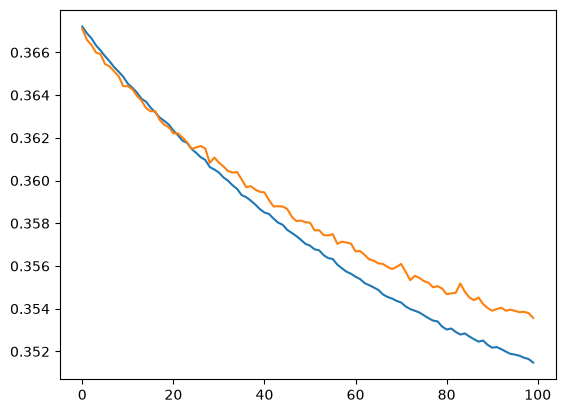

In [62]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [63]:
# this gaps tells the overfitting info 